In [1]:
from sequence_jacobian import create_model, ShockDict, AR
from sequence_jacobian.estimation import *

import numpy as np

In [2]:
from sequence_jacobian.examples.hank import *

household = hh.add_hetinputs([transfers, wages, make_grids])
household = household.add_hetoutputs([labor_supply])

blocks = [household, firm, monetary, fiscal, mkt_clearing, nkpc]
hank_model = create_model(blocks, name="One-Asset HANK")

In [3]:
calibration = {
    "r": 0.005,
    "rstar": 0.005,
    "eis": 0.5,
    "frisch": 0.5,
    "B": 5.6,
    "mu": 1.2,
    "rho_s": 0.966,
    "sigma_s": 0.5,
    "kappa": 0.1,
    "phi": 1.5,
    "Y": 1.0,
    "Z": 1.0,
    "pi": 0.,
    "nS": 2,
    "amax": 150,
    "nA": 10
}

In [4]:
unknowns_ss = {"beta": 0.986, "vphi": 0.8}
targets_ss = {"asset_mkt": 0.0, "NE": 1.0}

blocks_ss = [household, firm, monetary, fiscal, mkt_clearing, nkpc_ss]
hank_model_ss = create_model(blocks_ss, name="One-Asset HANK SS")

cali = hank_model_ss.solve_steady_state(
    calibration, unknowns_ss, targets_ss, solver="broyden_custom"
)

ss = hank_model.steady_state(cali)

In [5]:
unknowns = ["w", "Y", "pi"]
targets = ["asset_mkt", "goods_mkt", "nkpc_res"]
inputs = ["rstar", "Z"]
outputs = ["Y", "pi"]
T = 500

In [6]:
shocks = ShockDict({
    "rstar": AR(np.array([0.7]), 1.0),
    "Z": AR(np.array([0.8]), 0.5)
})

ar_prior = Prior({
    "phi": Uniform(-0.99, 0.99),
    "sigma": Uniform(0.05, 1.5)
})

shock_prior = Prior({i: ar_prior for i in inputs})

def shock_process(params):
    return ShockDict({
        "Z": AR(np.array([params["phi_Z"]]), params["sigma_Z"]),
        "rstar": AR(np.array([params["phi_rstar"]]), params["sigma_rstar"])
    })

In [7]:
from sequence_jacobian.utilities.shocks import simulate, get_responses
from sequence_jacobian.utilities.plotting import *

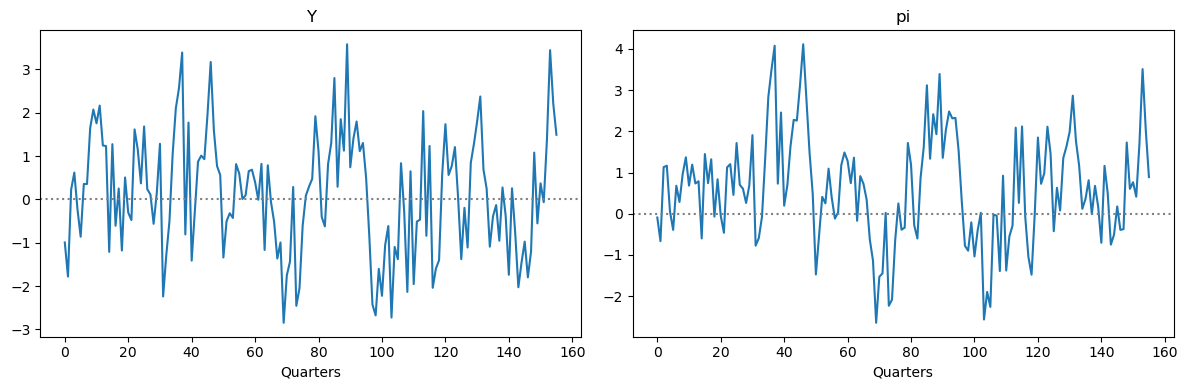

In [8]:
G = hank_model.solve_jacobian(ss, unknowns, targets, inputs, outputs, T=T)
shocks = shock_process(
    {"phi_Z": 0.8, "sigma_Z": 0.5, "phi_rstar": 0.7, "sigma_rstar": 1.0}
)

impulses = shocks.generate_impulses(T)
irfs = get_responses(impulses, G)

data_simul = simulate(irfs, outputs, 156)
plt = plot_timeseries(data_simul, figsize=(12, 4))

In [9]:
est_model = DensityModel(
    data_simul, ss, hank_model, shock_process,
    unknowns, targets, inputs, T=300, sigmas=np.full(1, 0.05)
)

In [10]:
prior = Prior({
    "phi_Z": Uniform(0.01, 0.99),
    "sigma_Z": InvGamma(3, 1),
    "phi_rstar": Uniform(0.01, 0.99),
    "sigma_rstar": InvGamma(3, 1),
})

In [11]:
mh_sampler = MetropolisHastings(est_model, prior, step_size=0.05)
mh_sampler.sample(10000)

100%|██████████| 9999/9999 [02:05<00:00, 79.81it/s] 


array([[0.        , 0.        , 0.        , 0.        ],
       [0.73812645, 0.24054033, 0.22982937, 0.3386188 ],
       [0.79702489, 0.37171928, 0.20642704, 0.25065339],
       ...,
       [0.84104541, 0.70288787, 0.45357395, 1.0270171 ],
       [0.84104541, 0.70288787, 0.45357395, 1.0270171 ],
       [0.84104541, 0.70288787, 0.45357395, 1.0270171 ]])

In [13]:
np.mean(mh_sampler.samples, axis=0)

array([0.81248586, 0.69372222, 0.51788363, 1.03700922])

In [14]:
mle = MaximumLikelihood(est_model, prior)
res = mle.optimize("scipy_lbfgsb", bounded=False)

In [15]:
res.x

{'phi_Z': 0.8174415523840539,
 'phi_rstar': 0.694950375733348,
 'sigma_Z': 0.5081544157166157,
 'sigma_rstar': 1.0382947408973624}